In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
os.getcwd()

'/Users/sheetalsuwalka/Documents/Project/XGBoost'

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(columns  = ['RowNumber'])

In [3]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.dtypes

CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [6]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [7]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [8]:
len(df['Surname'].unique())

2932

In [9]:
df_1 = df.drop(columns = ['Surname'])
df_1.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df_geo = pd.get_dummies(df['Geography'])
df_geo.head()

,France,Germany,Spain
0,1,0,0
1,0,0,1
2,1,0,0
3,1,0,0
4,0,0,1


In [11]:
df_gender = pd.get_dummies(df['Gender'])
df_gender.head()

,Female,Male
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [12]:
X = df_1.iloc[:,0:11]
Y = df_1.iloc[:,11]
X = X.drop(['Geography','Gender','CustomerId'], axis = 1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [13]:
X = pd.concat([X,df_geo,df_gender], axis = 1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1,0


In [14]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

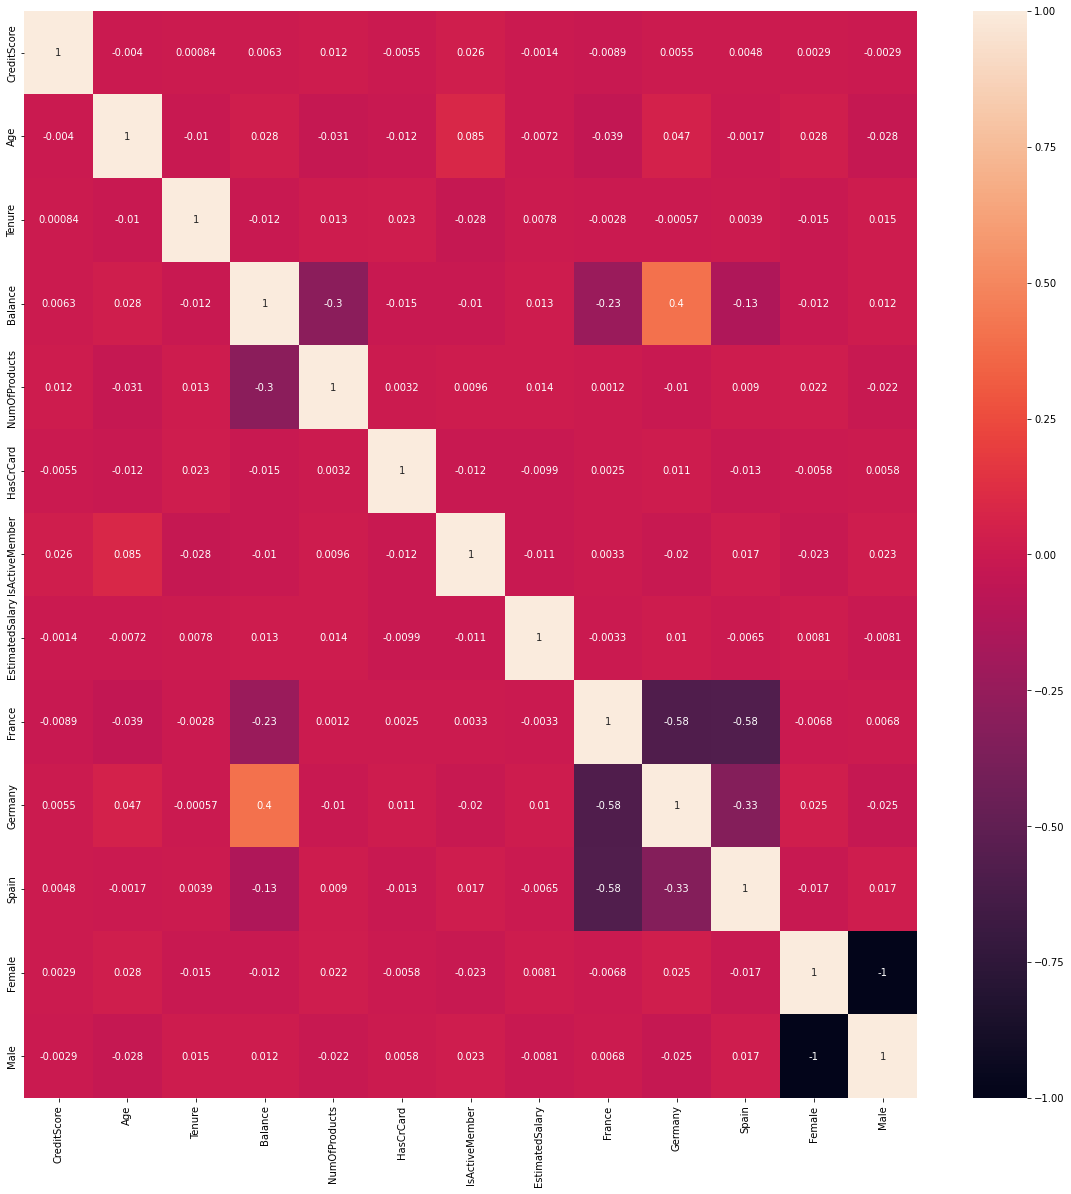

In [15]:
corr_matrix = X.corr()
plt.figure(figsize = (20,20))
p = sns.heatmap(corr_matrix, annot = True)

In [16]:
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [18]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
9254,686,32,6,0.00,2,1,1,179093.26,1,0,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,0,1,0,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,0,1,0,1
6087,561,27,9,135637.00,1,1,0,153080.40,1,0,0,1,0
6669,517,56,9,142147.32,1,0,0,39488.04,1,0,0,0,1


In [19]:
print('Training data size: ',(len(X_train), len(X_train.columns)))
print('Test data size: ',(len(X_test), len(X_test.columns)))

Training data size:  (8000, 13)
Test data size:  (2000, 13)


In [20]:
classifier = xgboost.XGBClassifier()
classifier.fit(X_train, Y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [21]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [22]:
Y_test

6252    0
4684    0
1731    0
4742    0
4521    0
       ..
6412    1
8285    0
7853    1
1095    1
6929    1
Name: Exited, Length: 2000, dtype: int64

In [23]:
accuracy = accuracy_score(Y_test, y_pred)
print('accuracy score :', accuracy)

accuracy score : 0.861


In [24]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1,0


In [25]:
from sklearn.preprocessing import MinMaxScaler

In [26]:
X['Balance_scaled'] = MinMaxScaler().fit_transform(X[['Balance']])
X['Salary_scaled'] = MinMaxScaler().fit_transform(X[['EstimatedSalary']])
X['credit_score_scaled'] = MinMaxScaler().fit_transform(X[['CreditScore']])
X['Age_scaled'] = MinMaxScaler().fit_transform(X[['Age']])
X = X.drop(['Balance','EstimatedSalary','CreditScore','Age'], axis = 1)


In [27]:
X.head()

,Tenure,NumOfProducts,HasCrCard,IsActiveMember,France,Germany,Spain,Female,Male,Balance_scaled,Salary_scaled,credit_score_scaled,Age_scaled
0,2,1,1,1,1,0,0,1,0,0.000000,0.506735,0.538,0.324324
1,1,1,0,1,0,0,1,1,0,0.334031,0.562709,0.516,0.310811
2,8,3,1,0,1,0,0,1,0,0.636357,0.569654,0.304,0.324324
3,1,2,0,0,1,0,0,1,0,0.000000,0.469120,0.698,0.283784
4,2,1,1,1,0,0,1,1,0,0.500246,0.395400,1.000,0.337838


In [28]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
log_clf  = LogisticRegression()
log_clf.fit(X_train, Y_train)

LogisticRegression()

In [31]:
log_y_pred = log_clf.predict(X_test)
log_y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [32]:
accuracy_score(Y_test,log_y_pred)

0.8005

In [33]:
classification_report(Y_test,log_y_pred)

'              precision    recall  f1-score   support\n\n           0       0.81      0.98      0.89      1607\n           1       0.45      0.07      0.12       393\n\n    accuracy                           0.80      2000\n   macro avg       0.63      0.53      0.51      2000\nweighted avg       0.74      0.80      0.74      2000\n'

In [34]:
confusion_matrix(Y_test,log_y_pred)

array([[1573,   34],
       [ 365,   28]])

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow.python.data import Dataset
import keras
from keras.utils import to_categorical
from keras import models
from keras import layers